In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
data_dir = 'static/data'
class_labels = ['backpack', 'book', 'bottle', 'calculator', 'chair', 'clock', 'desk', 'keychain', 'laptop', 'paper', 'pen', 'phone']
data = os.listdir(data_dir)

In [10]:
data_counts = []
for label in class_labels:
    count = 0
    for dir in data:
        if label in dir:
            count += len(os.listdir(os.path.join(data_dir, dir)))
    data_counts.append(count)

label_counts = dict(zip(class_labels, data_counts))
label_counts


{'backpack': 614,
 'book': 728,
 'bottle': 736,
 'calculator': 648,
 'chair': 627,
 'clock': 503,
 'desk': 588,
 'keychain': 626,
 'laptop': 728,
 'paper': 713,
 'pen': 765,
 'phone': 711}

In [12]:
label_to_idx = {label: i for i, label in enumerate(class_labels)}

matrix = np.zeros((len(class_labels), len(class_labels)), dtype=int)

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if not os.path.isdir(folder_path):
        continue

    labels = folder.split("_")
    if any(label not in label_to_idx for label in labels):
        continue

    for i, label_i in enumerate(labels):
        for label_j in labels[i:]:
            a = label_to_idx[label_i]
            b = label_to_idx[label_j]
            matrix[a, b] += len(os.listdir(folder_path))
            if a != b:
                matrix[b, a] += len(os.listdir(folder_path))

cooc_df = pd.DataFrame(matrix, index=class_labels, columns=class_labels)
cooc_df

,backpack,book,bottle,calculator,chair,clock,desk,keychain,laptop,paper,pen,phone
backpack,614,53,131,71,94,16,43,75,51,40,33,47
book,53,728,57,83,50,39,49,46,65,138,197,53
bottle,131,57,736,74,69,37,105,97,66,44,65,58
calculator,71,83,74,648,25,29,29,92,57,93,111,78
chair,94,50,69,25,627,23,148,38,90,34,34,41
clock,16,39,37,29,23,503,22,42,69,31,25,58
desk,43,49,105,29,148,22,588,40,131,57,48,63
keychain,75,46,97,92,38,42,40,626,44,62,53,83
laptop,51,65,66,57,90,69,131,44,728,52,81,127
paper,40,138,44,93,34,31,57,62,52,713,226,86


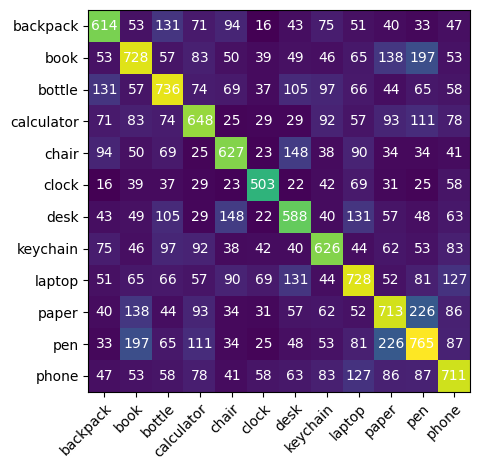

In [22]:
fig, ax = plt.subplots()
im = ax.imshow(cooc_df)

ax.set_yticks(range(len(class_labels)), labels=class_labels)
ax.set_xticks(range(len(class_labels)), labels=class_labels, 
            rotation=45, rotation_mode='anchor', ha='right')

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        text = ax.text(j, i, cooc_df.iloc[i, j], ha="center", va="center", color="w")
fig.tight_layout()
plt.show()